# 연합학습 (Federated Learning)

연합학습은 분산 머신러닝 패러다임의 하나로, 다수의 기기에서 데이터 정보를 노출하지 않으면서 학습하는 방법이다.  
연합학습을 사용하는 이유는 다양하지만 크게 세 가지 이유로 정리 할 수 있다.  

* 보안성: 사용자 혹은 기관은 자신의 데이터를 노출하지 않으면서도 전체 데이터를 학습할 수 있다.
* 저장 효율성: 모든 기기에서 발생한 데이터를 한 곳에 저장하고 학습하는 것은 물리적으로 어렵다.  
* 연산 가능성: 컴퓨팅 연산력을 하나의 큰 서버에서 각 기기로 옮길 수 있다. 

# 연합학습의 5단계
### 0단계: 글로벌 모델 초기화

서버에서 글로벌 모델을 초기화하는 것으로 시작합니다.

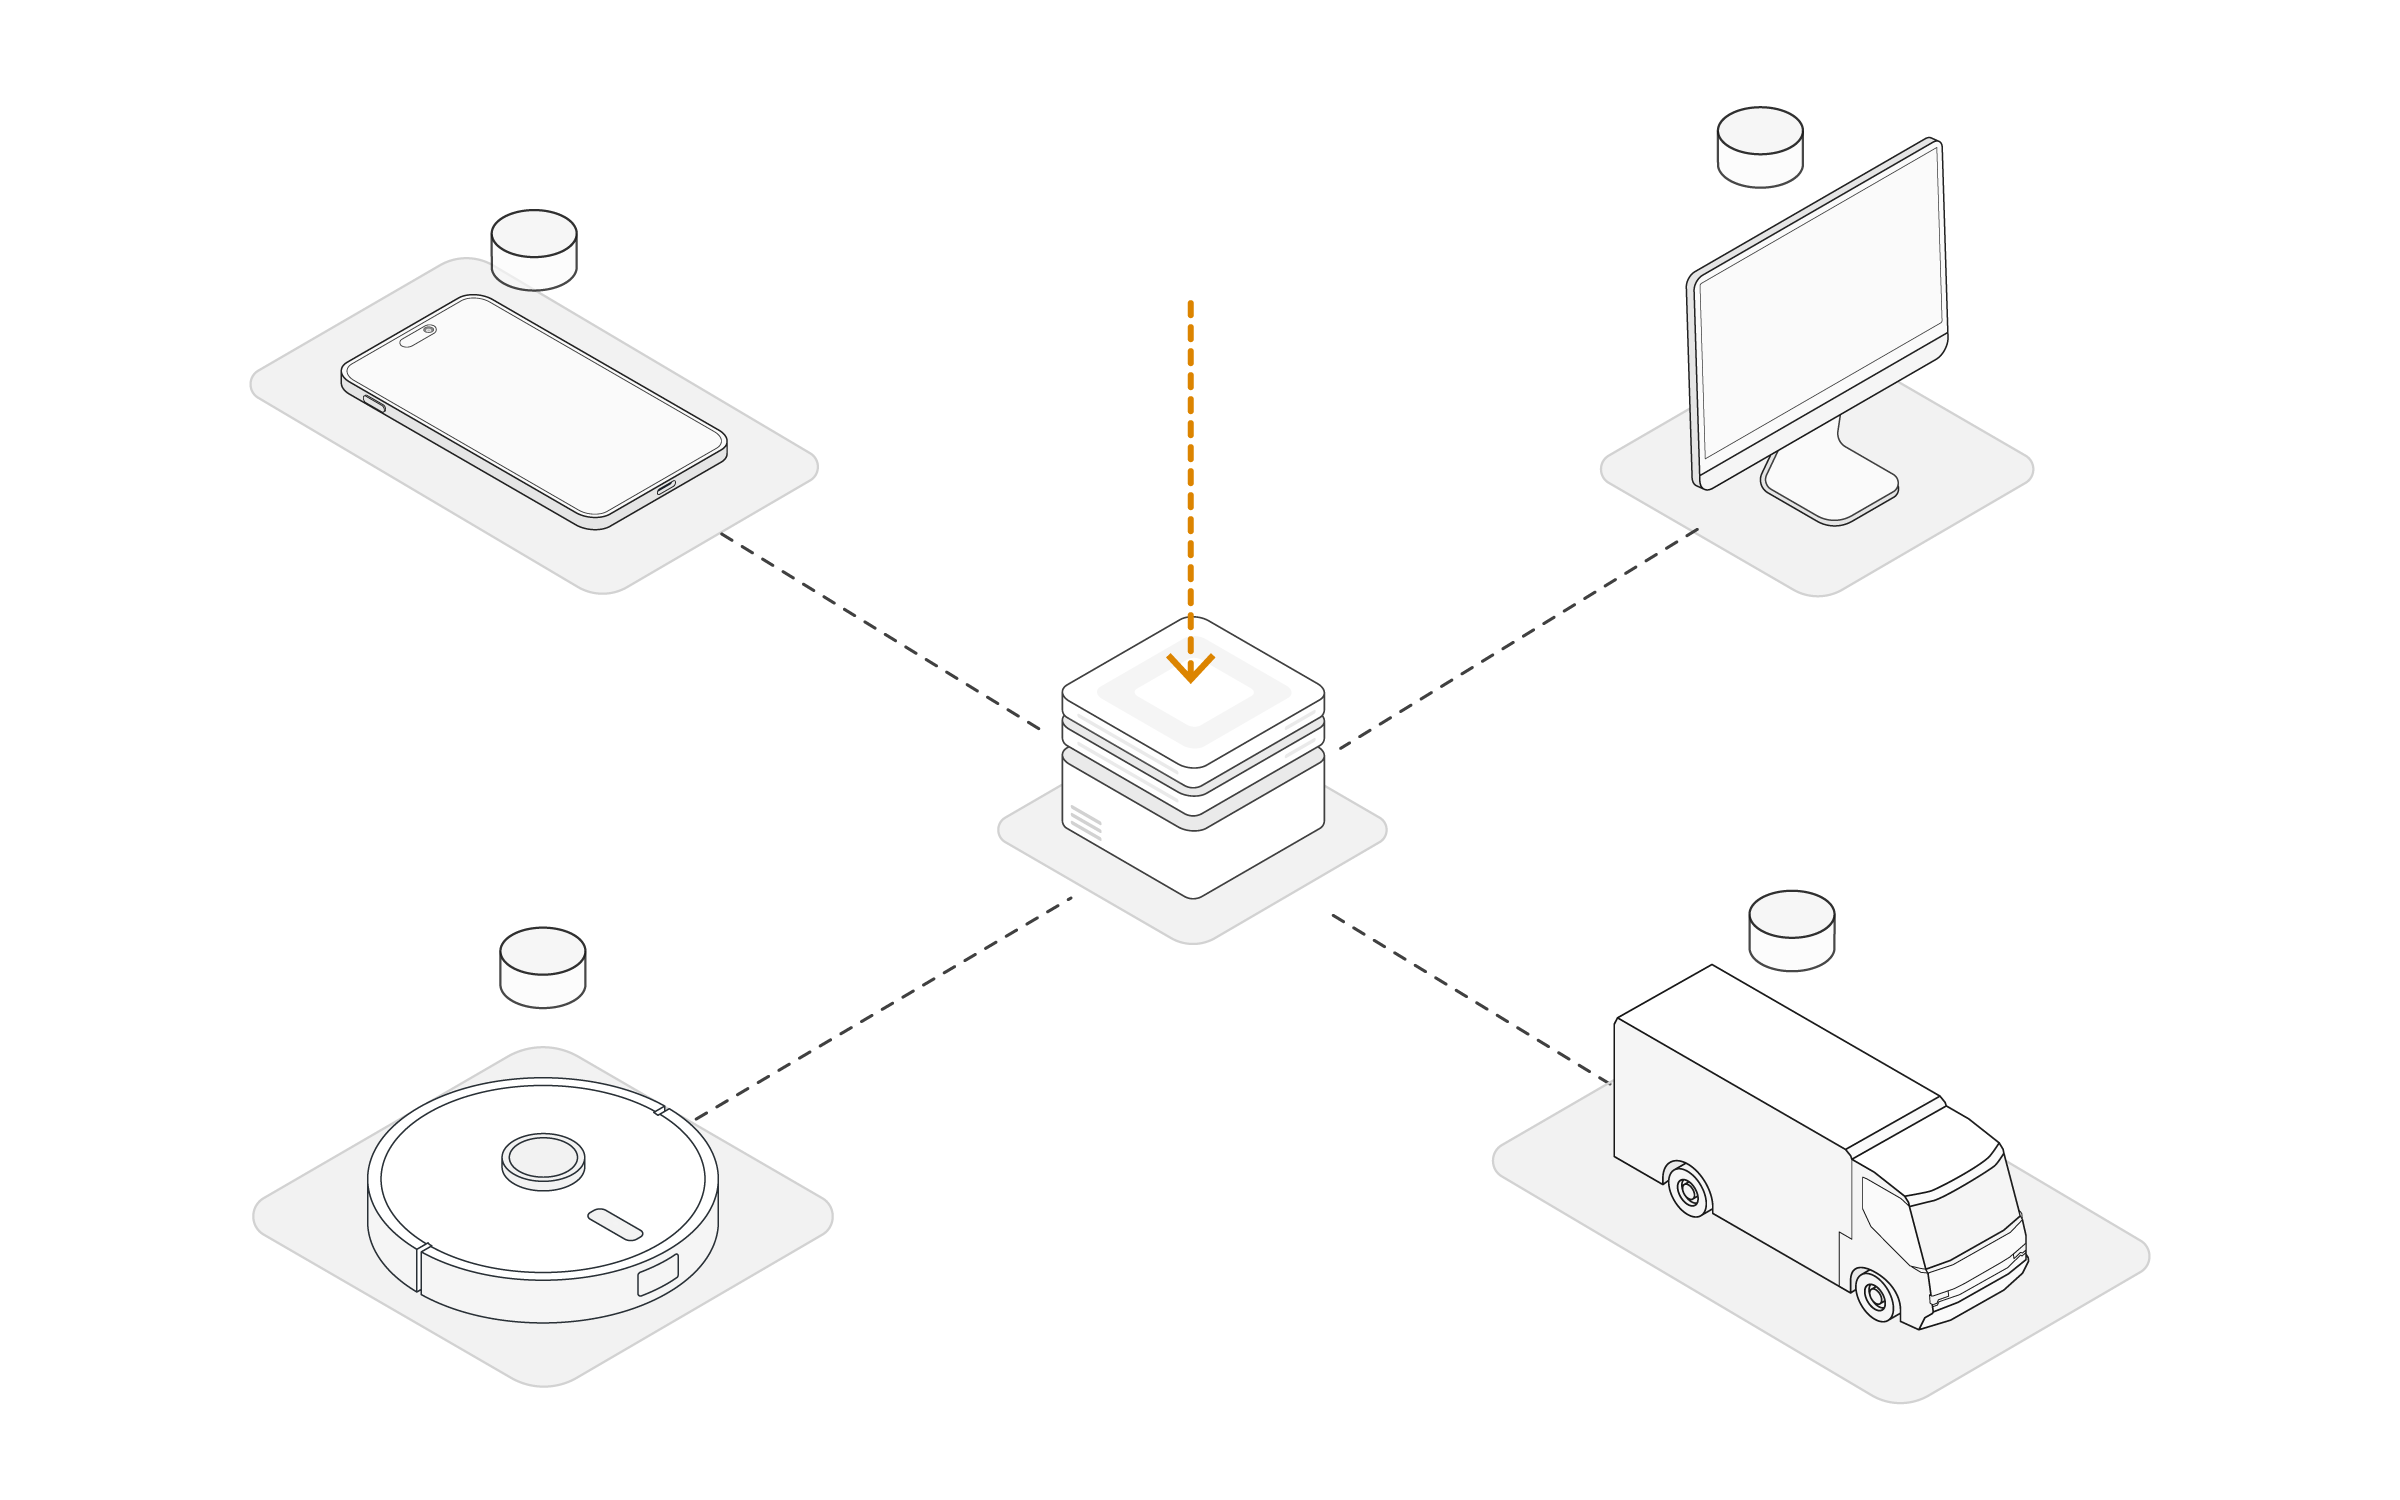

### 1단계: 연결된 여러 조직/장치 (클라이언트 노드)에 모델 전송

글로벌 모델의 가중치(=parameter)를 연결된 클라이언트 노드에 전송합니다.  
이와 같은 방식에서 각 학습에 참여하는 노드들이 같은 모델로 학습을 진행합니다.  
일반적으로 연결된 모든 노드 대신 일부의 노드로 학습을 진행합니다.  

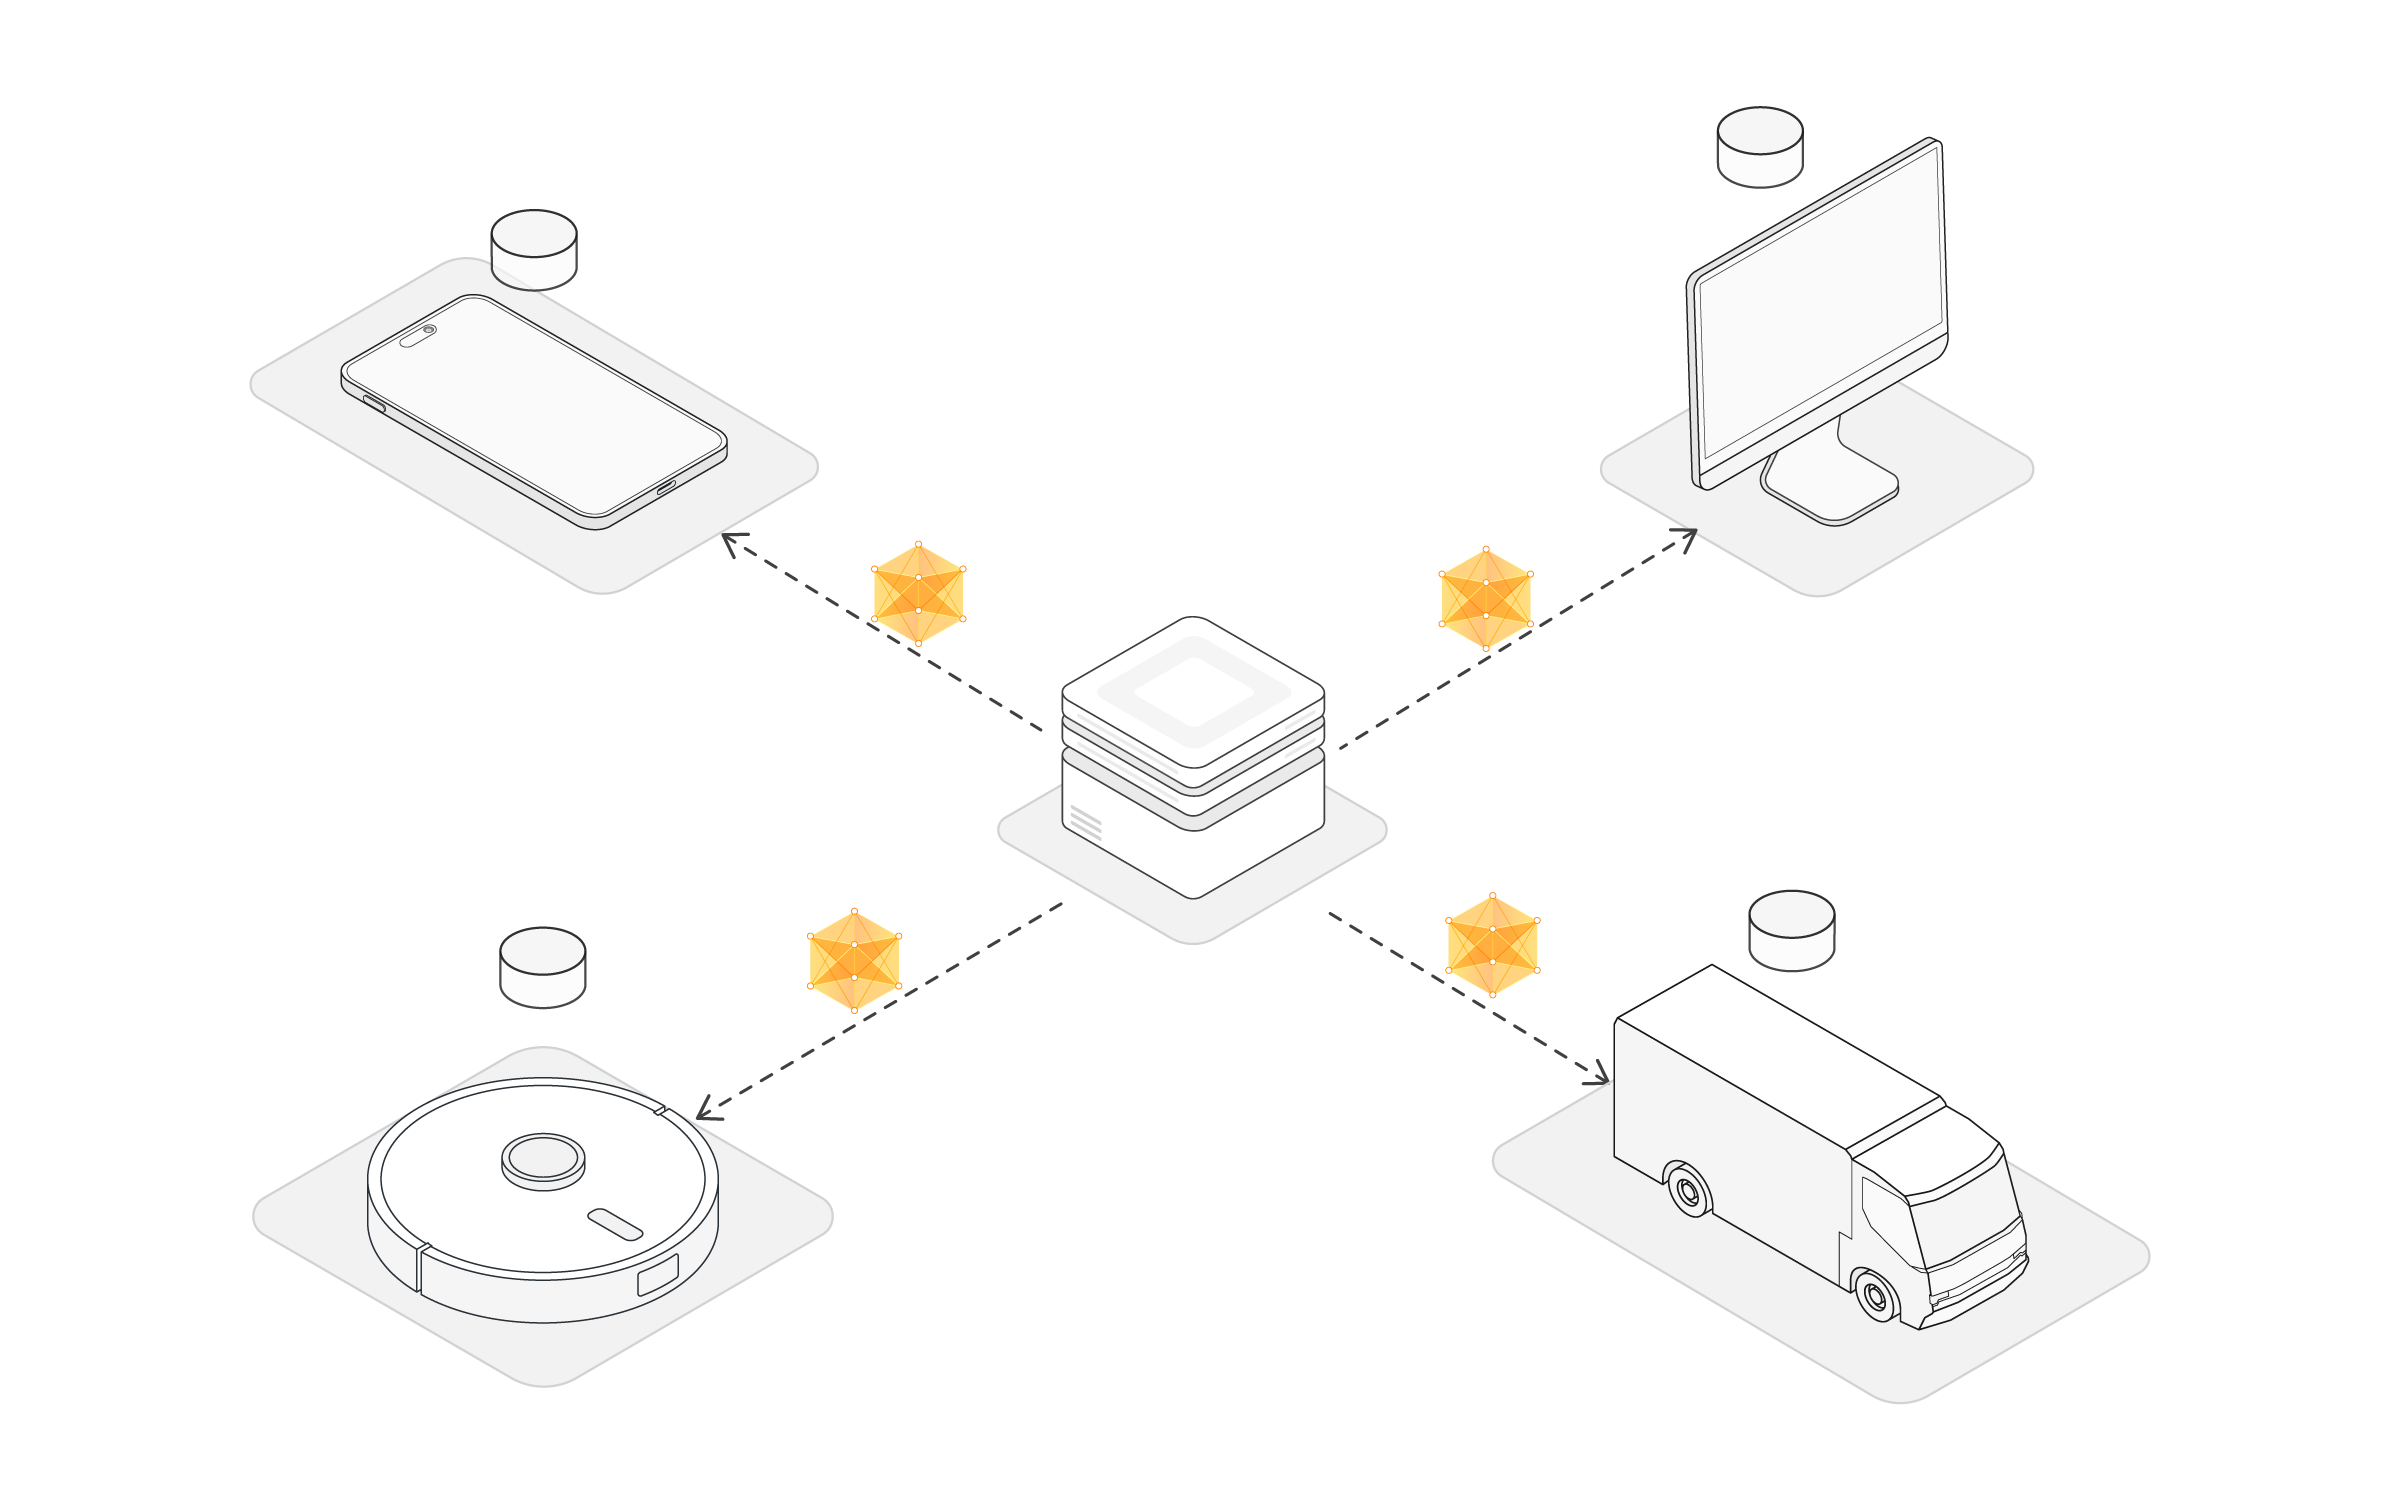


### 2단계: 각 클라이언트 노드의 데이터에 대해 노드 내에서(로컬) 모델 학습

이제 학습에 포함된 클라이언트 노드에는 최신 버전의 글로벌 모델 파라미터가 있으며 로컬 학습을 시작합니다.  
각 클라이언트 노드의 로컬 모델은 자신의 로컬 데이터 셋을 사용하여 학습합니다.  

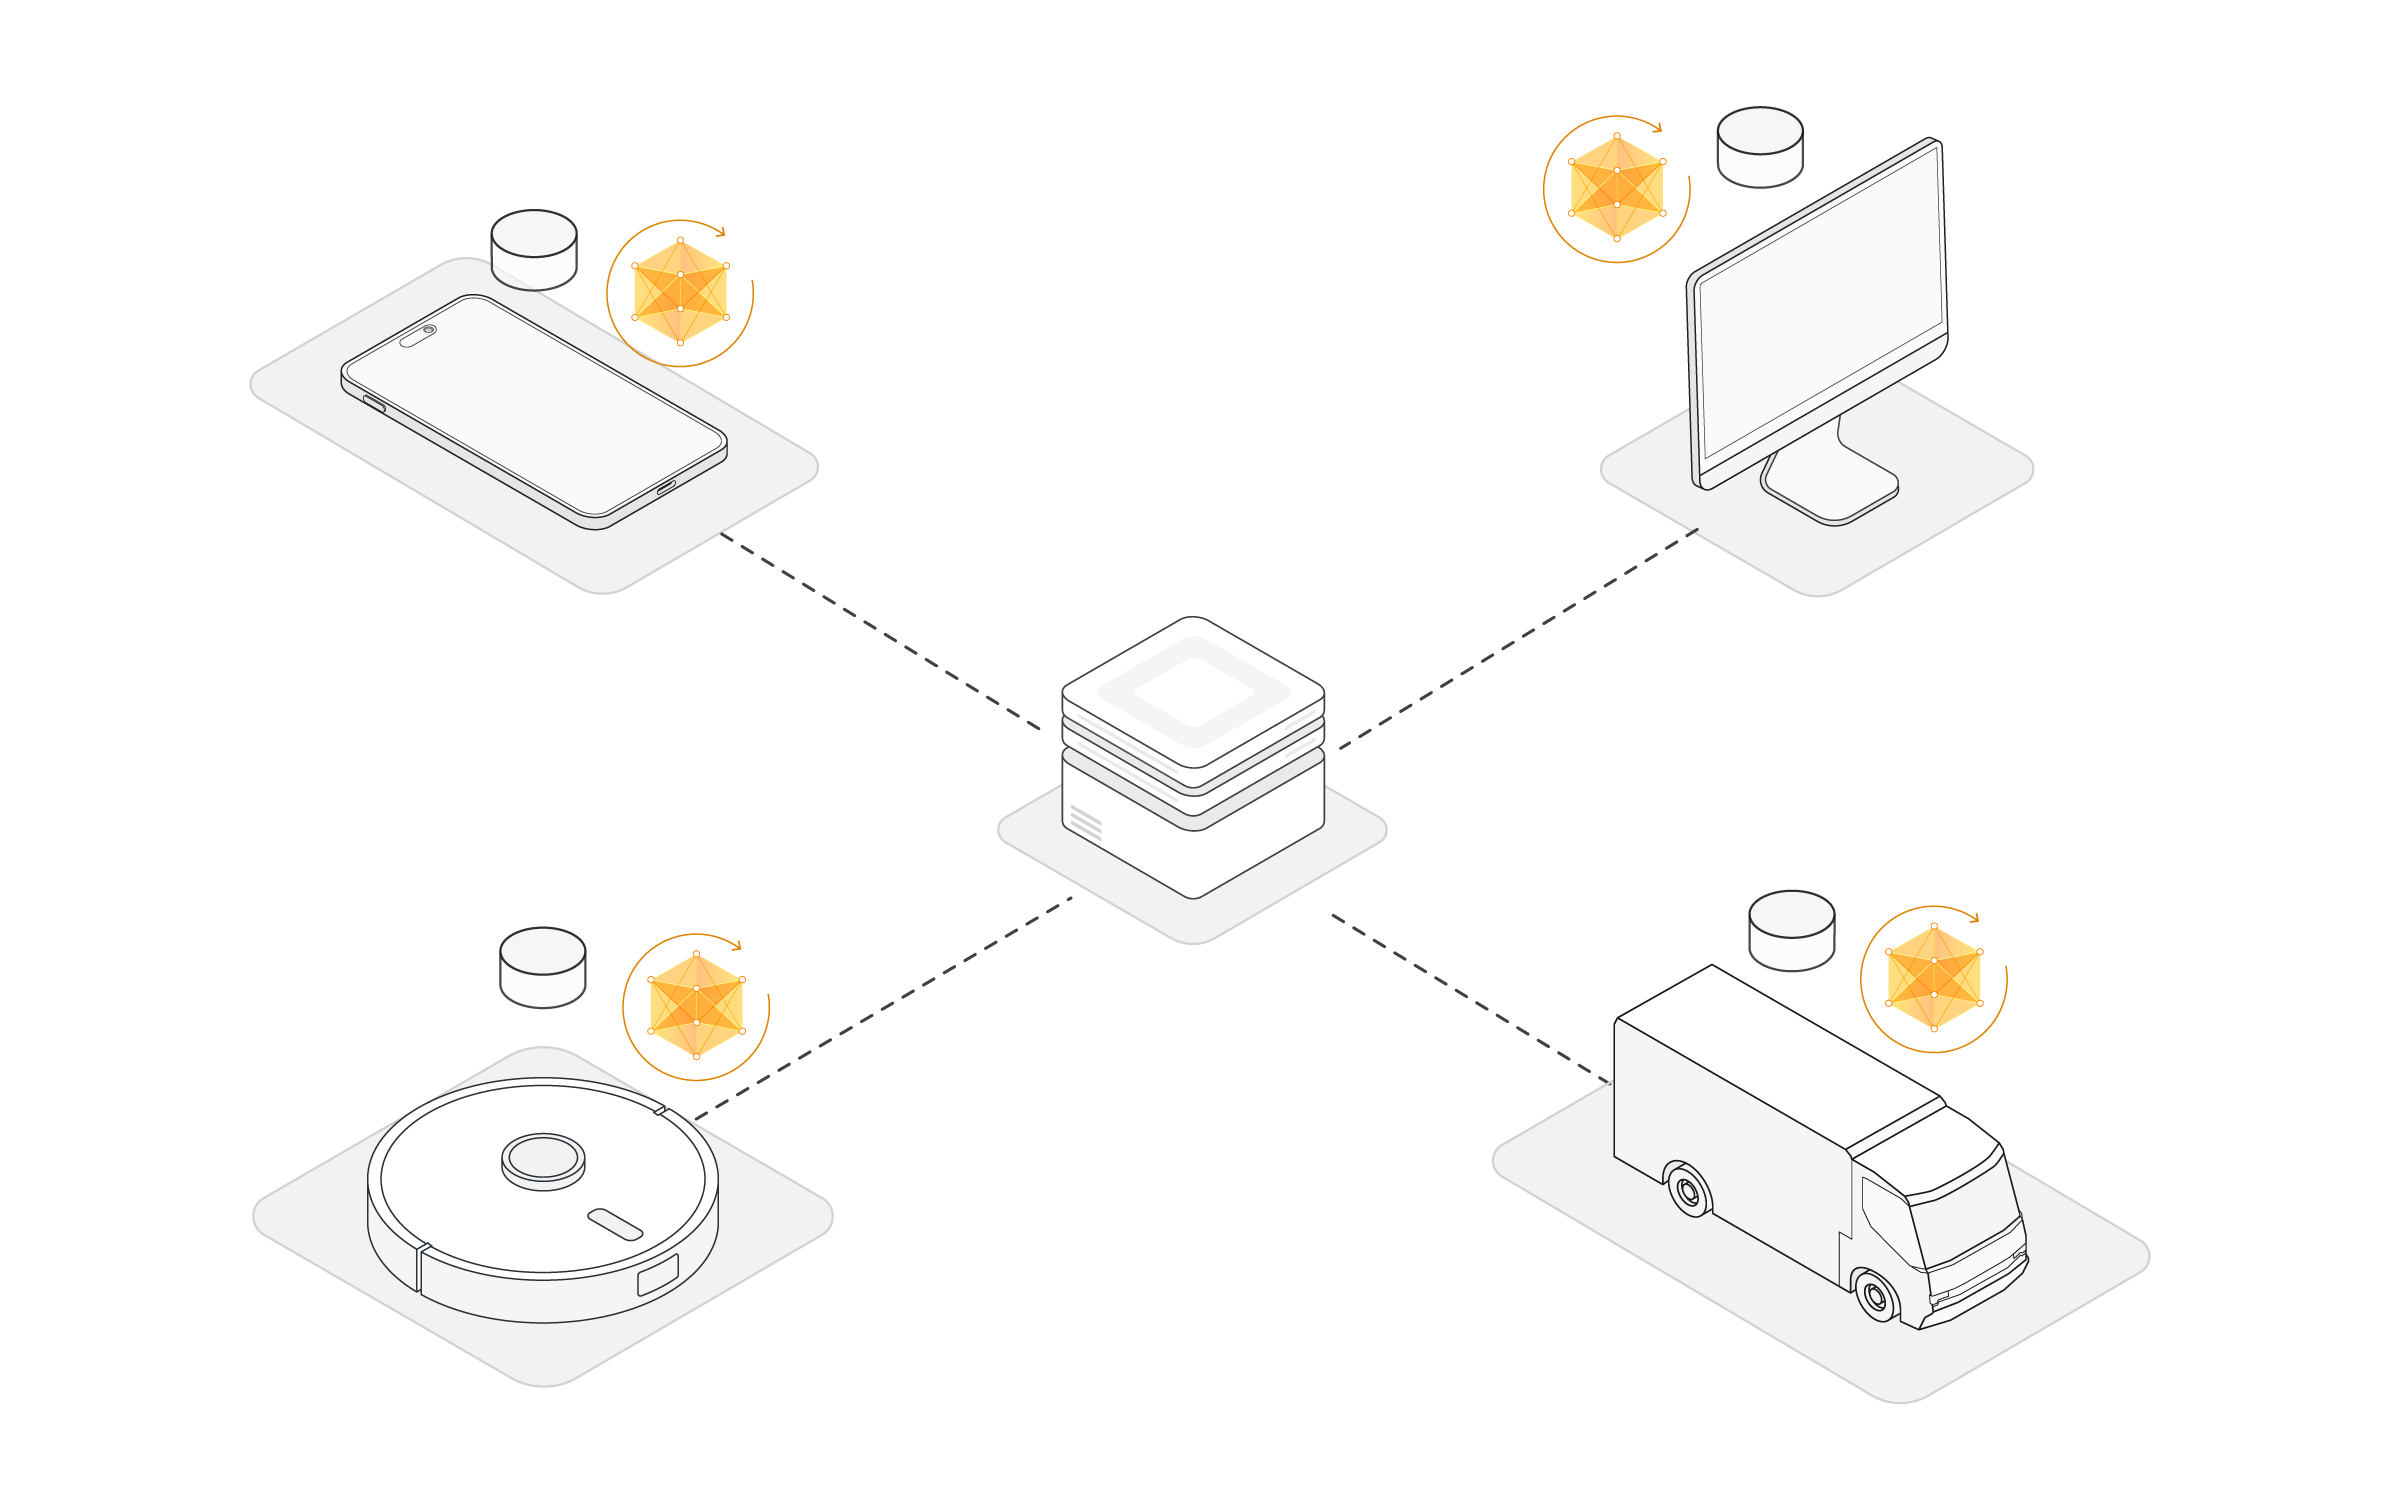


### 3단계: 모델 파라미터를 업데이트하여 서버로 반환

로컬 훈련 후에는 클라이언트 노드마다 모델 파라미터가 다릅니다. (각 모델마다 학습한 데이터가 상이하므로...)   
각 클라이언트 노드는 이렇게 업데이트 된 모델 파라미터를 서버로 반환합니다.  

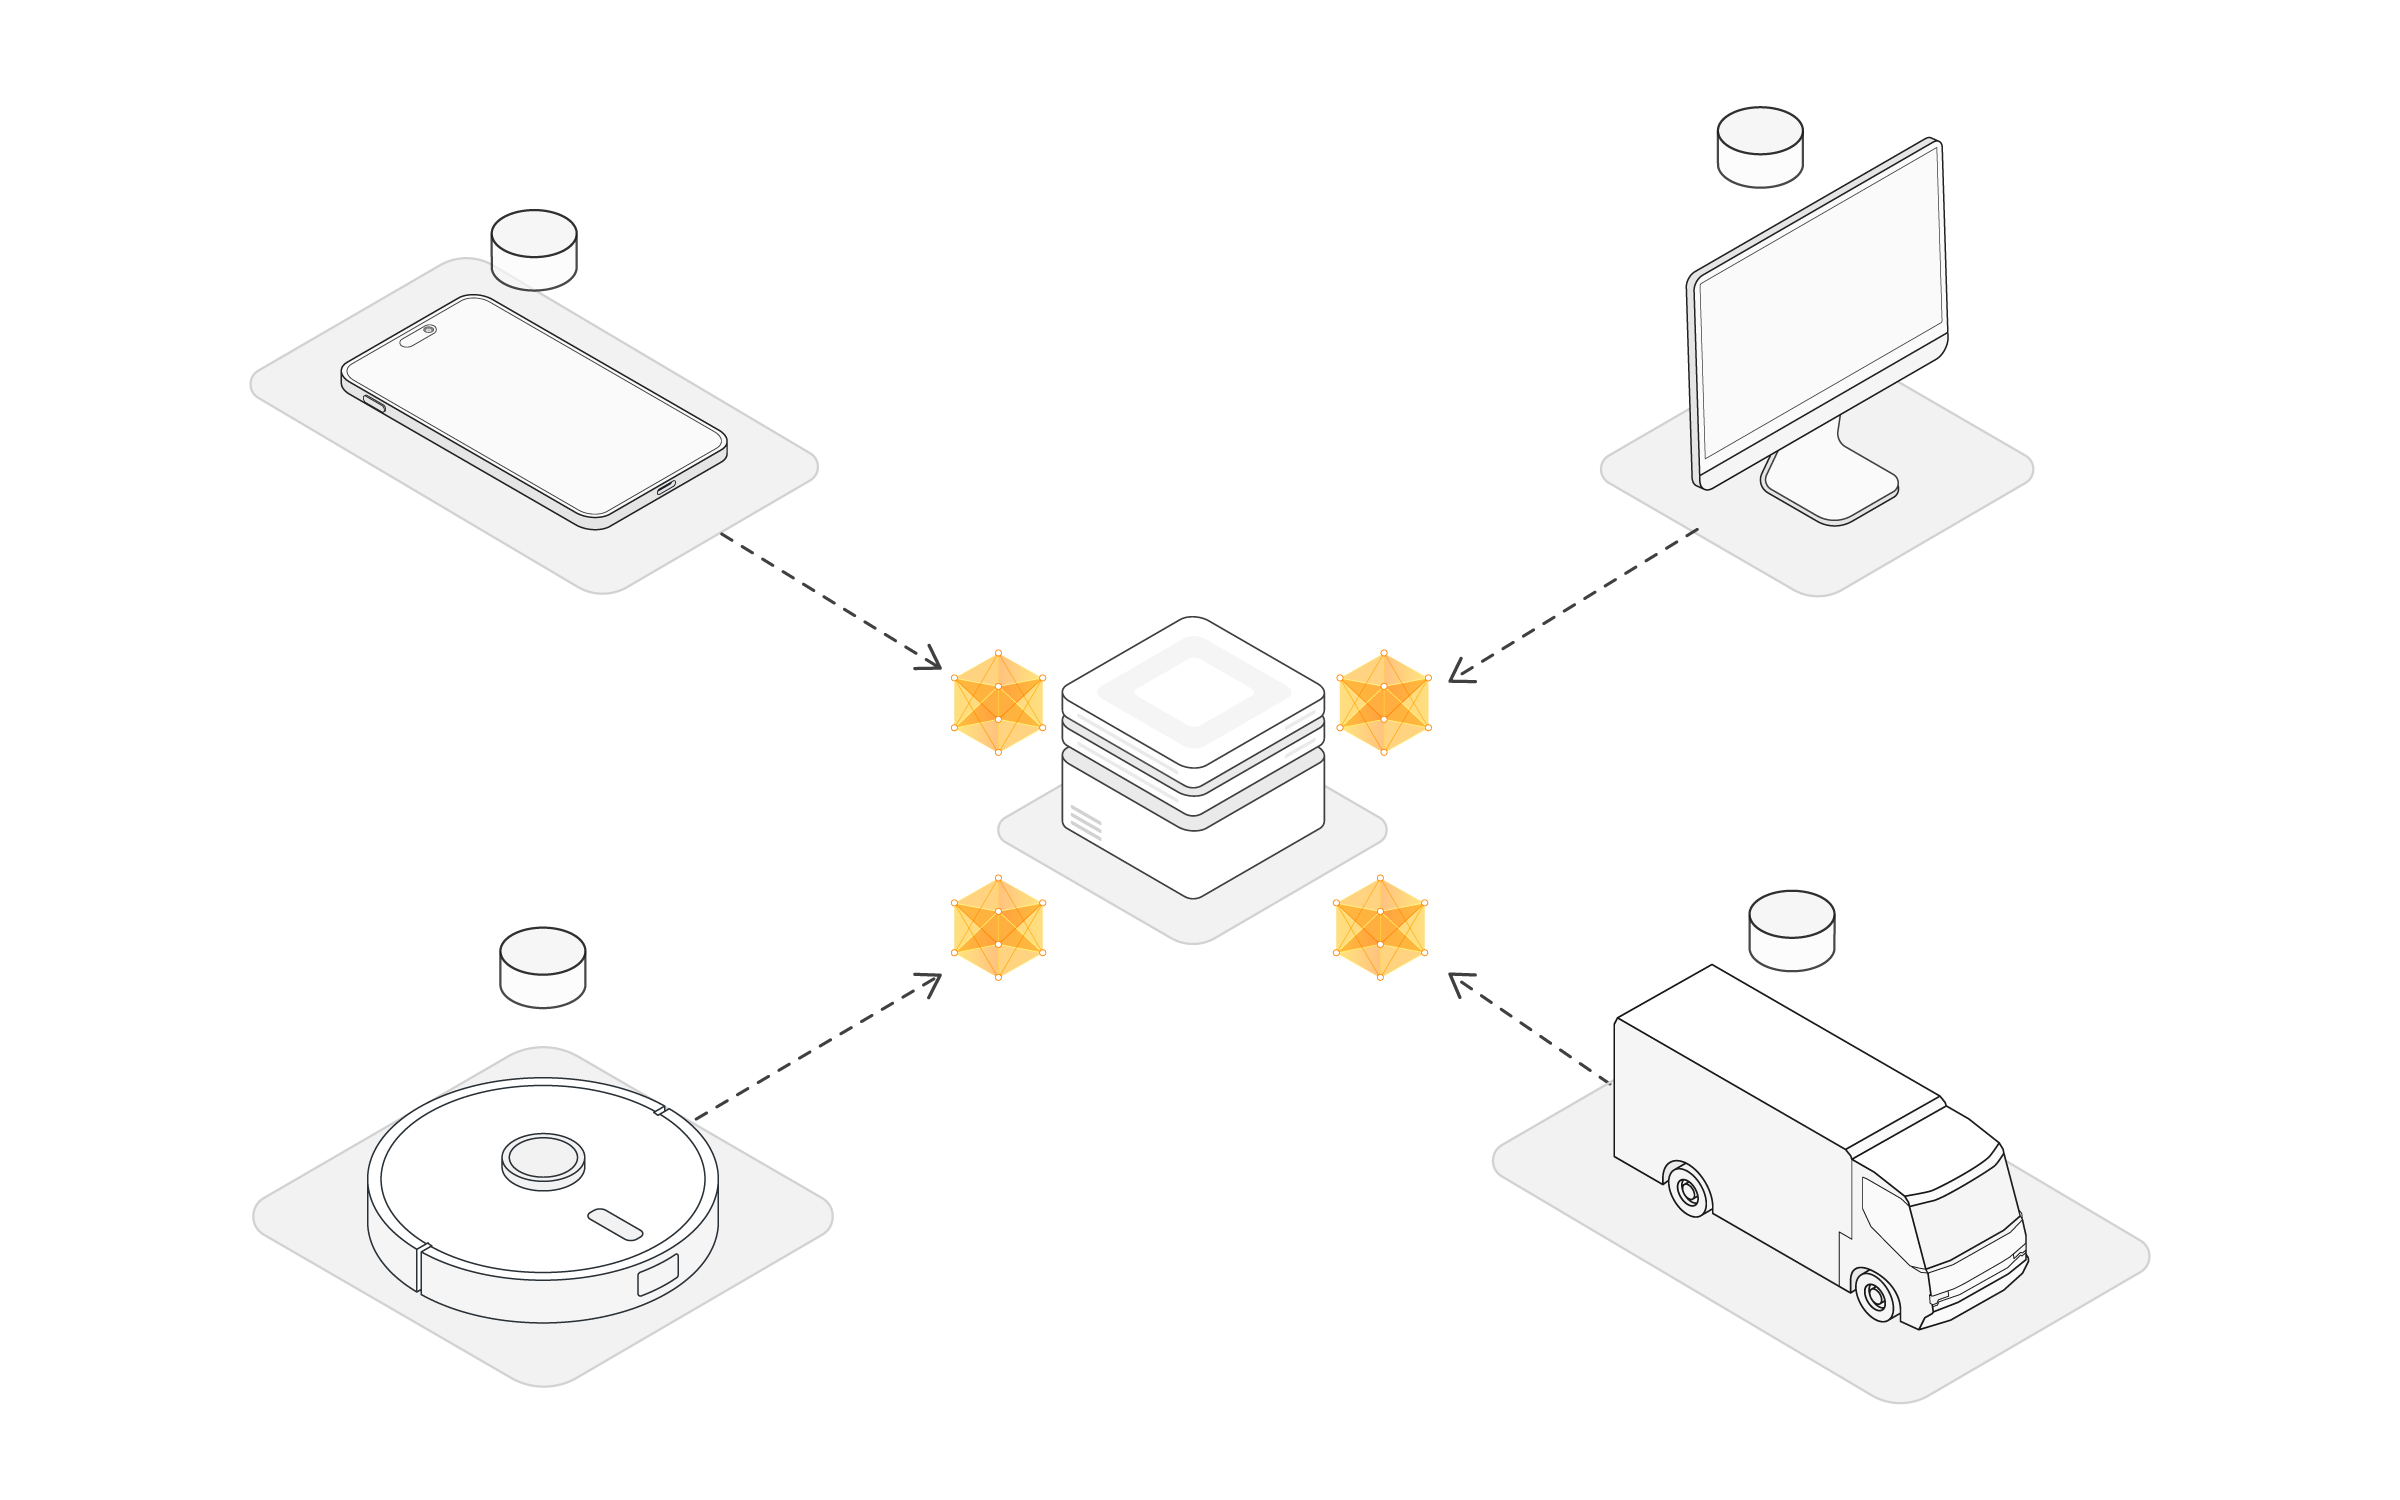


### 4단계: 모델 업데이트를 새 글로벌 모델로 집계

서버는 업데이트 받은 모델 파라미터를 수신합니다.  
서버가 100개의 클라이언트 노드를 선택했다면 이제 각각 클라이언트의 로컬 데이터를 기반으로 훈련된 100개의 조금씩 다르게 업데이트된 글로벌 모델들을 가지게 됩니다.  
이 100개의 업데이트된 모델들을 하나의 모델로 처리하기위해 일반적인 방법인 Federated Averaging을 수행합니다.  

글로벌 모델의 파라미터 셋 = {$W_1, W_2, \dots ,W_n$}   
$W_n = \frac{1}{100} \sum\limits_{i=1}^{100} W_i^n$,   
$W_i^n$이 클라이언트 $i$의 $n$번째 weight


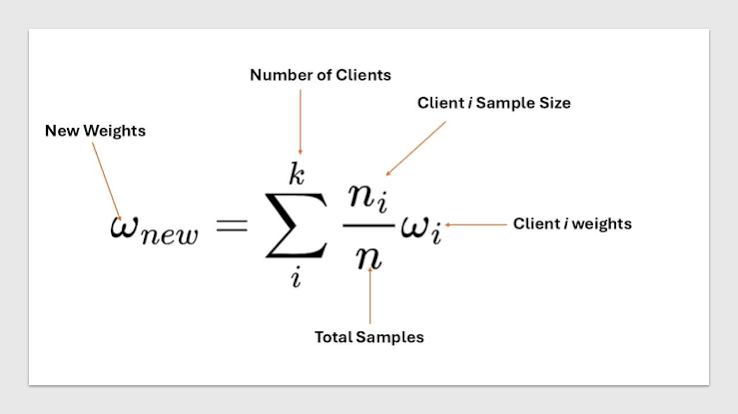


### 5단계: 모델이 수렴할 때까지 1~4단계를 반복

이제 서버에서 100개의 업데이트된 모델들이 하나의 새로운 글로벌 모델로 합쳐짐.  
이제 새로운 글로벌 모델을 다시 클라이언트 노드에 전송하고 앞에 단계를 반복함.  
이를 반복하면 데이터 셋을 중앙서버로 옮기지 않고도 모델의 학습이 가능함!


*출처: [Flower Framework 공식 튜토리얼](https://flower.ai/docs/framework/main/ko/tutorial-series-what-is-federated-learning.html)*


[연합학습 참고 링크](https://www.ibm.com/kr-ko/think/topics/federated-learning)

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import copy

# 1. 하이퍼파라미터 설정
# 클라이언트 노드의 갯수
NUM_CLIENTS = 2
# 클라이언트와 서버간의 통신 라운드 수
GLOBAL_ROUNDS = 5
# 클라이언트 내에서 로컬 학습을 수행하는 epoch
LOCAL_EPOCHS = 2
# 로컬 데이터 셋을 한 번에 학습 시키는건 비효율적!
# 따라서 데이터를 나누어서 학습을 진행하는데 그때 한 번에 학습시키는 데이터의 양을 배치 사이즈라고 한다.
BATCH_SIZE = 64
# 학습률 (learning rate)
LR = 0.01

# 2. MNIST 데이터셋 로드 및 클라이언트 분할 (IID 환경 가정)
# 실제 연합학습 상황을 가정하기 위해 데이터 셋을 클라이언트 수만큼 `균등하게` 분할하는 방식 
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# MNIST 데이터 셋 다운로드 및 로드
train_dataset = datasets.MNIST(root='./data', train=True, download=False, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=False, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

# 데이터를 클라이언트 수만큼 균등하게 분할
total_samples = len(train_dataset)
samples_per_client = total_samples // NUM_CLIENTS
client_loaders = []

for i in range(NUM_CLIENTS):
    indices = list(range(i * samples_per_client, (i + 1) * samples_per_client))
    subset = Subset(train_dataset, indices)
    loader = DataLoader(subset, batch_size=BATCH_SIZE, shuffle=True)
    client_loaders.append(loader)

# 3. 모델 정의 (간단한 CNN)
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2), # 공간 크기 축소 및 이동 불변성 확보
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1) # Flatten
        return self.fc(x)

# 4. 로컬 클라이언트 학습 함수
def local_train(model, train_loader, epochs):
    model.train()
    optimizer = optim.SGD(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()
    
    for epoch in range(epochs):
        for data, target in train_loader:
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
    return model.state_dict()

# 5. 글로벌 모델 평가 함수
def evaluate_global_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in test_loader:
            output = model(data)
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
            total += target.size(0)
    accuracy = 100. * correct / total
    return accuracy

# 6. FedAvg 알고리즘 중심의 메인 루프
global_model = SimpleCNN()

print("🚀 연합학습 시뮬레이션 시작...")
for r in range(GLOBAL_ROUNDS):
    print(f"\n--- Global Round {r + 1} ---")
    local_weights = []
    
    # 각 클라이언트는 글로벌 모델을 복사하여 로컬 학습 수행 (Local Update)
    for client_idx in range(NUM_CLIENTS):
        # 글로벌 모델 가중치 복사
        local_model = SimpleCNN()
        local_model.load_state_dict(global_model.state_dict())
        
        # 로컬 데이터로 가중치 업데이트
        updated_weight = local_train(local_model, client_loaders[client_idx], LOCAL_EPOCHS)
        local_weights.append(updated_weight)
        print(f"Client {client_idx + 1} 학습 완료")
        
    # 7. 서버에서 가중치 평균화 (Federated Averaging)
    # 각 클라이언트의 데이터 크기가 같으므로 단순 평균(Simple Average) 계산
    fedavg_weights = copy.deepcopy(local_weights[0])
    for key in fedavg_weights.keys():
        for i in range(1, NUM_CLIENTS):
            fedavg_weights[key] += local_weights[i][key]
        fedavg_weights[key] = torch.div(fedavg_weights[key], NUM_CLIENTS)
        
    # 글로벌 모델 업데이트
    global_model.load_state_dict(fedavg_weights)
    
    # 라운드 종료 후 테스트 성능 평가
    acc = evaluate_global_model(global_model, test_loader)
    print(f"Round {r + 1} 글로벌 모델 정확도: {acc:.2f}%")

print("\n🎉 학습 완료!")

🚀 연합학습 시뮬레이션 시작...

--- Global Round 1 ---
Client 1 학습 완료
Client 2 학습 완료
Round 1 글로벌 모델 정확도: 93.86%

--- Global Round 2 ---
Client 1 학습 완료
Client 2 학습 완료
Round 2 글로벌 모델 정확도: 96.50%

--- Global Round 3 ---
Client 1 학습 완료
Client 2 학습 완료
Round 3 글로벌 모델 정확도: 97.11%

--- Global Round 4 ---
Client 1 학습 완료
Client 2 학습 완료
Round 4 글로벌 모델 정확도: 97.82%

--- Global Round 5 ---
Client 1 학습 완료
Client 2 학습 완료
Round 5 글로벌 모델 정확도: 98.32%

🎉 학습 완료!
